# TODO 1.4.

- MAR assumption: generating coverage from the mag. field
    - repeat analysis with coverage masked data

In [1]:
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

from pathlib import Path
from itertools import product
from sklearn.impute import KNNImputer
from numpy.lib.stride_tricks import sliding_window_view
from IPython.display import clear_output

from aipad.padimputer import PADImputer
from aipad.spacecrafts import SoloConstants, WindConstants
from aipad.datahandler import WindDataHandler
from aipad.pad_imputation import (
    make_train_test, pad_histogram, target_from_prediction)

In [2]:
bins = 8
time_avg_min = 1
avg_bin = f"{time_avg_min}min_{bins}bins"

file_path = Path("./data/hdf5") / f"wind_{avg_bin}.h5"
cov_path = Path("./data/coverages") / avg_bin
plot_path = Path(f"./plots/")

plot_path.mkdir(exist_ok=True)

solo = SoloConstants()
wind = WindConstants()

### Simple imputation strategies: row/column mean, average of forward and backward fill, linear interpolation, KNN without train-test split


In [3]:
results_path = Path(".") / "minmax_scaled_results"
results_path.mkdir(exist_ok=True)

imputer = PADImputer(wind)

miss_pcts = np.arange(10, 81, 10)

events = pd.read_csv("events.csv")
for event_no in range(len(events)):
    event_key = events.values[event_no][0]
    if event_key.split("-")[0] > "20120930":
        break
    for method, axis, miss_pct in product(["fill_average", "interp"], ["time", "pitch_angle"], miss_pcts):
        imputer.axis = 0 if axis == "time" else 1
        imputer.method = method
        imputer.run_analysis(event_key, miss_pct, repeats=50, scale="min_max",
                             fname=f"{event_key}_{imputer.method}_axis{imputer.axis}_{miss_pct}pct",
                             file_path=file_path, results_path=results_path,
                             show_plot=False, save_plot=False)
    clear_output()

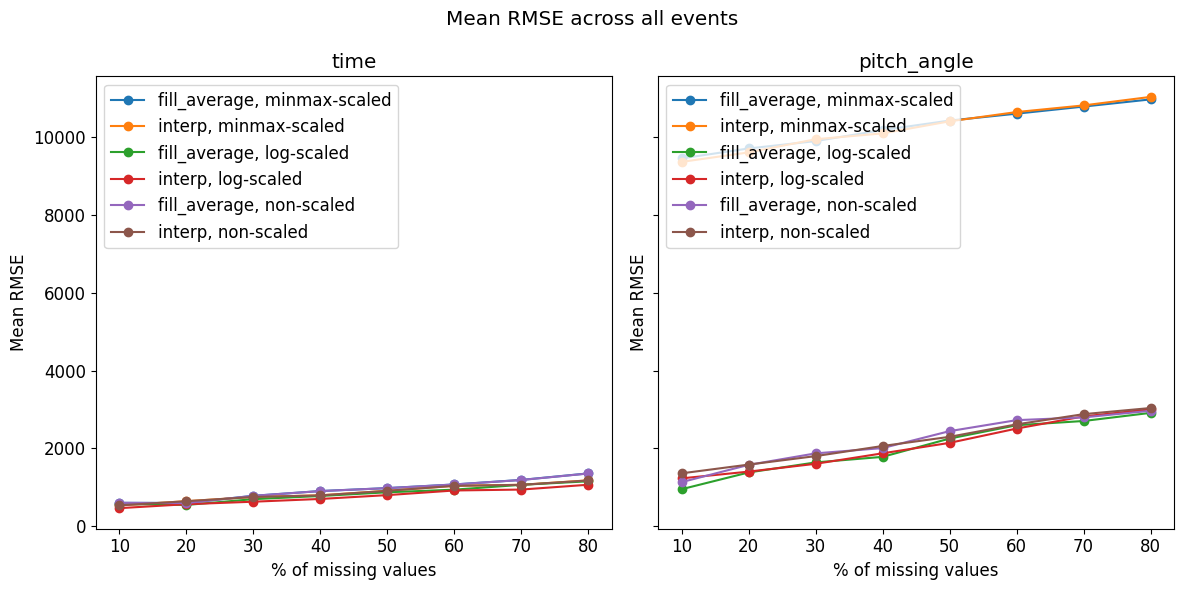

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import os

row_vars = ["time", "pitch_angle"]
col_vars = ["fill_average", "interp"]
fig, axs = plt.subplots(ncols=2, figsize=(12, 6), sharex=True, sharey=True)
fig.suptitle("Mean RMSE across all events")

for scale in ["minmax", "log", "non"]:
    results_path = Path(f"/home/ojsant/gradu/{scale}_scaled_results")
    means = pd.read_csv(f"/home/ojsant/gradu/{scale}_scaled_results/20120728-220737.csv", header=[0, 1], index_col=[0, 1])["rmse_mean"]
    stds = pd.read_csv(f"/home/ojsant/gradu/{scale}_scaled_results/20120728-220737.csv", header=[0, 1], index_col=[0, 1])["rmse_std"]
    #base_arr = np.zeros((8,4))
    dfs_mean = []
    dfs_std = []
    for i, csv in enumerate(os.listdir(results_path)):
        dfs_mean.append(pd.read_csv(results_path / csv, header=[0, 1], index_col=[0, 1])["rmse_mean"].to_numpy())
        dfs_std.append(pd.read_csv(results_path / csv, header=[0, 1], index_col=[0, 1])["rmse_std"].to_numpy())

    means.iloc[:] = np.nanmean(np.stack(dfs_mean), axis=0)
    #stds.iloc[:] = np.nanmean(np.stack(dfs_std), axis=0)

    pcts = means.columns.astype(int)
    # Plot data
    for i, axis in enumerate(row_vars):
        for method in col_vars:
            axs[i].errorbar(pcts, means.loc[(method, axis)].values, yerr=None, fmt="o-", capsize=5, label=f"{method}, {scale}-scaled")
        axs[i].set_title(axis)
        axs[i].legend(loc="upper left")
        axs[i].set_xlabel(r"% of missing values")
        axs[i].set_ylabel("Mean RMSE")

plt.tight_layout()
plt.show()

In [7]:
means

miss_percent                       10           20           50           80
method       axis                                                           
mean         time         3692.976521  3730.494788  3888.736752  3991.436310
             pitch_angle  2407.177928  2448.920658  2788.398070  3067.650205
fill_average time          506.432205   674.781572   884.834853  1266.804028
             pitch_angle  1116.443538  1600.408793  2390.727702  2985.623926
interp       time          715.785867   555.204030   936.324184  1129.791928
             pitch_angle  1207.903137  1536.340768  2279.179908  2897.480531
knn          time          895.153573  1364.804047  1869.723454  2174.275594
             pitch_angle  2149.783500  2316.379922  2827.288760  3088.528302

### KNN with vs. without training

In [3]:
import subprocess
miss_pcts = [10, 20, 30, 40, 50, 60, 70, 80]
for n_neighbors in [1, 5, 15, 20]:
    for miss_pct in miss_pcts:
        rc = subprocess.run(("python3", "knn_train_test_analysis.py", str(miss_pct), str(n_neighbors)))

['knn_train_test_analysis.py', '10', '1']
Event 20120102-153731
Event 20120102-153731 with 10 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 42.057
RMSE std: 11.389
Event 20120127-183733
Event 20120127-183733 with 10 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 1077.572
RMSE std: 190.869
Event 20120306-062237
Event 20120306-062237 with 10 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 7628.424
RMSE std: 11963.921
Event 20120330-002250
Event 20120330-002250 with 10 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 78.817
RMSE std: 4.620
Event 20120407-055234
Event 20120407-055234 with 10 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 22.455
RMSE std: 0.945
Event 20120411-055234
Event 20120411-055234 with 10 % MCAR missingness: results using method 'knn' along time axis
RMSE mean: 64.220
RMSE std: 8.436
Event 20120423-230730
Event 20120423-230730 with 10 %

/tmp/ipykernel_14437/3598219367.py:18: RuntimeWarning: Mean of empty slice
  mean_rmses = np.nanmean(dfs, axis=0)


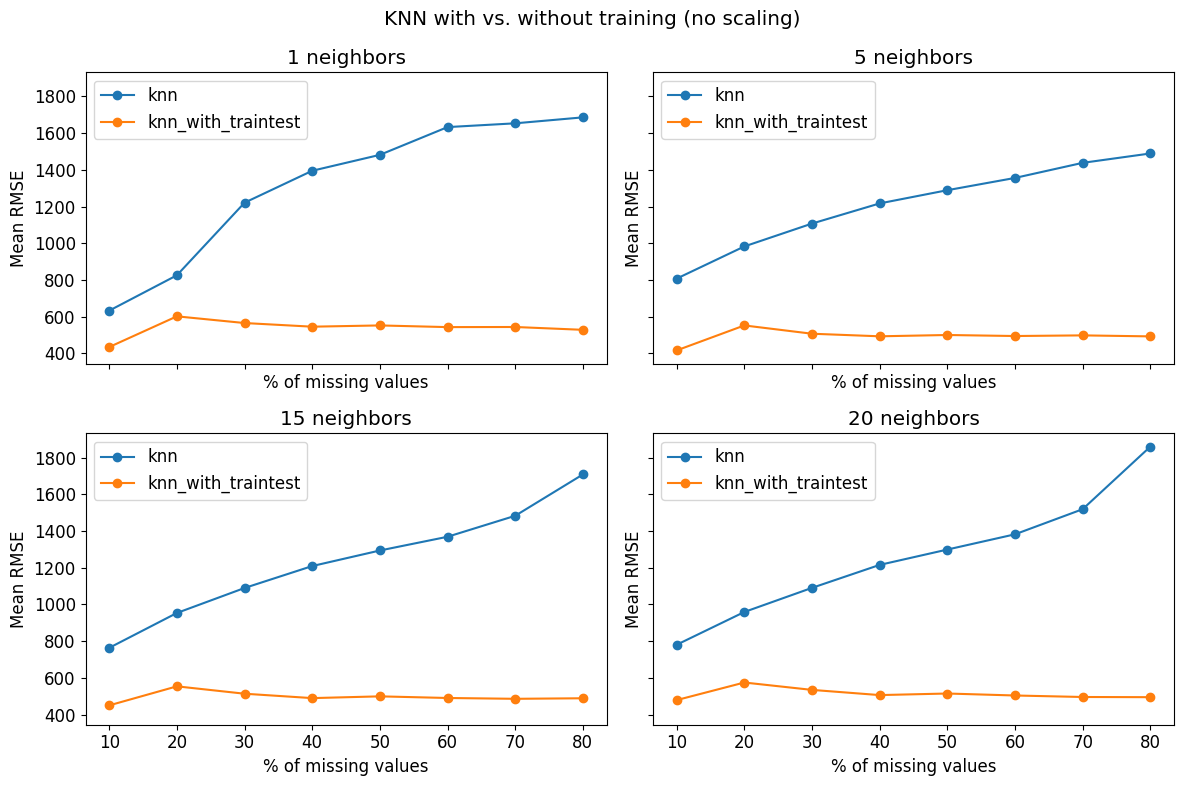

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

os.chdir("/home/ojsant/gradu/knn_results")
means = pd.read_csv("/home/ojsant/gradu/knn_results/20120102-153731.csv", header=[0, 1], index_col=[0, 1, 2])["rmse_mean"]
# stds = means.copy()

dfs = []
for i, csv in enumerate(os.listdir()):
    try:
        dfs.append(pd.read_csv(csv, header=[0, 1], index_col=[0, 1, 2])["rmse_mean"].to_numpy())
    except IsADirectoryError:
        continue

dfs = np.stack(dfs)
mean_rmses = np.nanmean(dfs, axis=0)
means.iloc[:] = mean_rmses
# std_rmses = np.std(dfs, axis=0, ddof=1)
# stds.iloc[:] = std_rmses
pcts = means.columns.astype(int)

fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(12, 8), sharex=True, sharey=True)
fig.suptitle("KNN with vs. without training (no scaling)")
# Plot data
for i, n_neighbors in enumerate([1, 5, 15, 20]):
    ax = axs.ravel()[i]
    ax.plot(pcts, means.loc[("knn", "time", f"{n_neighbors}n")].values, "o-", label="knn")
    ax.plot(pcts, means.loc[("knn_with_traintest", "time", f"{n_neighbors}n")].values, "o-", label="knn_with_traintest")
    ax.legend(loc="upper left")
    ax.set_title(f"{n_neighbors} neighbors")
    ax.set_xlabel(r"% of missing values")
    ax.set_ylabel("Mean RMSE")
plt.tight_layout()

In [6]:
pd.read_csv(csv, header=[0, 1], index_col=[0, 1, 2])["rmse_mean"]

miss_percent                                       10         20         30  \
method             axis        n_neighbors                                    
knn                time        1n           45.139253  51.502496  59.099167   
                               5n           36.215821  38.704324  42.718115   
                               15n          36.206317  37.405965  40.198452   
                               20n          36.317484  37.352590  39.985739   
                   pitch_angle 1n                 NaN        NaN        NaN   
                               5n                 NaN        NaN        NaN   
                               15n                NaN        NaN        NaN   
                               20n                NaN        NaN        NaN   
knn_with_traintest time        1n           47.716632  35.614181  34.929592   
                               5n           27.536833  35.912039  35.683949   
                               15n          24.910777  36.206087  34.558530   
                               20n          26.736980  32.769422  31.926917   
                   pitch_angle 1n                 NaN        NaN        NaN   
                               5n                 NaN        NaN        NaN   
                               15n                NaN        NaN        NaN   
                               20n                NaN        NaN        NaN   

miss_percent                                       40         50         60  \
method             axis        n_neighbors                                    
knn                time        1n           62.116969  63.599669  65.170687   
                               5n           46.386637  48.944822  50.537925   
                               15n          42.978795  45.535237  47.909461   
                               20n          42.634053  45.194380  47.825637   
                   pitch_angle 1n                 NaN        NaN        NaN   
                               5n                 NaN        NaN        NaN   
                               15n                NaN        NaN        NaN   
                               20n                NaN        NaN        NaN   
knn_with_traintest time        1n           33.355148  38.824687  45.317656   
                               5n           32.793044  32.289376  39.432085   
                               15n          31.718596  31.201163  38.433563   
                               20n          29.931513  29.381842  36.868535   
                   pitch_angle 1n                 NaN        NaN        NaN   
                               5n                 NaN        NaN        NaN   
                               15n                NaN        NaN        NaN   
                               20n                NaN        NaN        NaN   

miss_percent                                       70          80  
method             axis        n_neighbors                         
knn                time        1n           67.206111   70.237171  
                               5n           52.297071   57.465413  
                               15n          51.848948   87.768931  
                               20n          55.413737  106.741852  
                   pitch_angle 1n                 NaN         NaN  
                               5n                 NaN         NaN  
                               15n                NaN         NaN  
                               20n                NaN         NaN  
knn_with_traintest time        1n           47.542227   46.445466  
                               5n           40.599897   36.838211  
                               15n          39.337357   36.350892  
                               20n          37.997872   34.889276  
                   pitch_angle 1n                 NaN         NaN  
                               5n                 NaN         NaN  
                               15n                NaN         NaN 

In [35]:
means

10           20           50  \
method             n_neighbors                                          
knn                1n            855.486714  1485.837765  2322.312293   
                   5n           1362.052511  1721.245381  2020.851684   
                   10n          1173.704813  1553.739106  2022.826144   
                   15n          1153.908294  1527.181089  1956.550005   
knn_with_traintest 1n           1015.086366  1286.312706  2649.260626   
                   5n           1078.768963  1252.493870  2685.596241   
                   10n          1070.245019  1212.493320  2685.854895   
                   15n          1084.319932  1351.491811  2539.750224   

                                         80  
method             n_neighbors               
knn                1n           2641.019495  
                   5n           2370.978847  
                   10n          2438.823655  
                   15n          2561.492452  
knn_with_traintest 1n           5986.730115  
                   5n           3909.078625  
                   10n          3513.086140  
                   15n          3306.354593

### KNNImputer CV (with blocks)

In [ ]:
# Stacking of training cases for KNN imputer:
# concatenate 5 successive rows to one feature vector (5 * 180 = 900 features)
trains = []
for train in X_train:
    train_stacked = sliding_window_view(train, window_shape=(5,180)).reshape(-1, 5 * train.shape[1])   # ChatGPT solution
    trains.append(train_stacked)

X_train_stacked = np.vstack(trains)

In [ ]:
import logging
import sys
filehandler = logging.FileHandler(filename="./logs/cv_results.log", encoding="utf-8")
streamhandler = logging.StreamHandler(sys.stdout)
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(message)s', datefmt='%m/%d/%Y %H:%M:%S', handlers=[filehandler, streamhandler], force=True)

def form_test_matrices_blocks(model: KNNImputer, X_test: np.ndarray,
                       y_test: np.ndarray, n_samples=10, sample_loc=120) -> list:
    true = X_test[sample_loc:sample_loc+n_samples]
    test = y_test[sample_loc:sample_loc+n_samples]
    reduced = np.where(np.isfinite(test), true, np.nan)
    
    reduced_reshaped = reduced.reshape((2, 900))
    pred_full_reshaped = model.transform(reduced_reshaped)
    pred_full = pred_full_reshaped.reshape((10, 180))

    pred = np.where((np.isnan(reduced)
                    & np.isfinite(true)
                    & np.meshgrid(np.isfinite(reduced).any(axis=1), np.arange(0, reduced.shape[1]),
                                  indexing="ij")[0]),
                    pred_full, np.nan)
    target = np.where(np.isfinite(pred), true, np.nan)

    return [true, reduced, pred_full, pred, target]

# Model selection CV
neighbors = np.arange(0, 31, 5)
neighbors[0] = 1
#weights = ["distance", "uniform"]      10.2. no noticeable difference between these
n_splits = 3
n_events = 20
n_samples = 10
sample_loc = 120 # onset is located at two hours after start of the window

# Cross validation: shift train-test split by one 3 times (a sort of 3-fold CV),
# but test only 10 samples in each event (after onset) and only 20 events in each fold

for n in neighbors:
    imputer = KNNImputer(n_neighbors=n, weights="distance", keep_empty_features=True)
    
    for shift in range(n_splits):
        logging.info(f"KNN neighbors={n}, split {shift}")
        result_df = pd.DataFrame()
        (X_train, X_test, y_train, y_test,
        I_train, I_test, meta_train, meta_test) = make_train_test(hist_arr, reduced_hist_arr,
                                                                intensity_arr, metadata_arr,
                                                                n=n_splits, shift=shift)
        trains = []
        for train in X_train:
            train_stacked = sliding_window_view(train, window_shape=(5, train.shape[1])).reshape(-1, 5 * train.shape[1])   # ChatGPT solution
            trains.append(train_stacked)

        X_train_stacked = np.vstack(trains)
        imputer.fit(X_train_stacked)
        scores = []
        for j in range(20):
            res = form_test_matrices_blocks(imputer, X_test[j], y_test[j])
            # plot_results(model, res, "rmse", I_test[j], sc=wind, cov_sc=solo,
            #              save_path=plot_path / "knnimputer" / "crossvalidation" / f"knn_{n}_{w}_split_{shift}_results_{j}.png")
            
            # Score on n_samples samples during main event
            score = calculate_scores(res[3],
                                     res[4], "rmse")
            result_df = save_results(imputer, res, meta_test[j], "rmse", Path(f"./knn_{n}_split_{shift}_results.csv"))
            scores.append(score)
            logging.info(f"Score for test event {j}: {score}")

        clear_output()
        logging.info(f"KNN neighbors={n}: CV score on fold {shift}={np.mean(scores):.4f}")


02/10/2026 12:46:53 KNN neighbors=15, weights=uniform: CV score on fold 2=2407.7693


Event 20120122-030734 with 50 % MCAR missingness: results using method 'cubic2d' along pitch_angle axis
RMSE mean: 0.035
RMSE std: 0.001


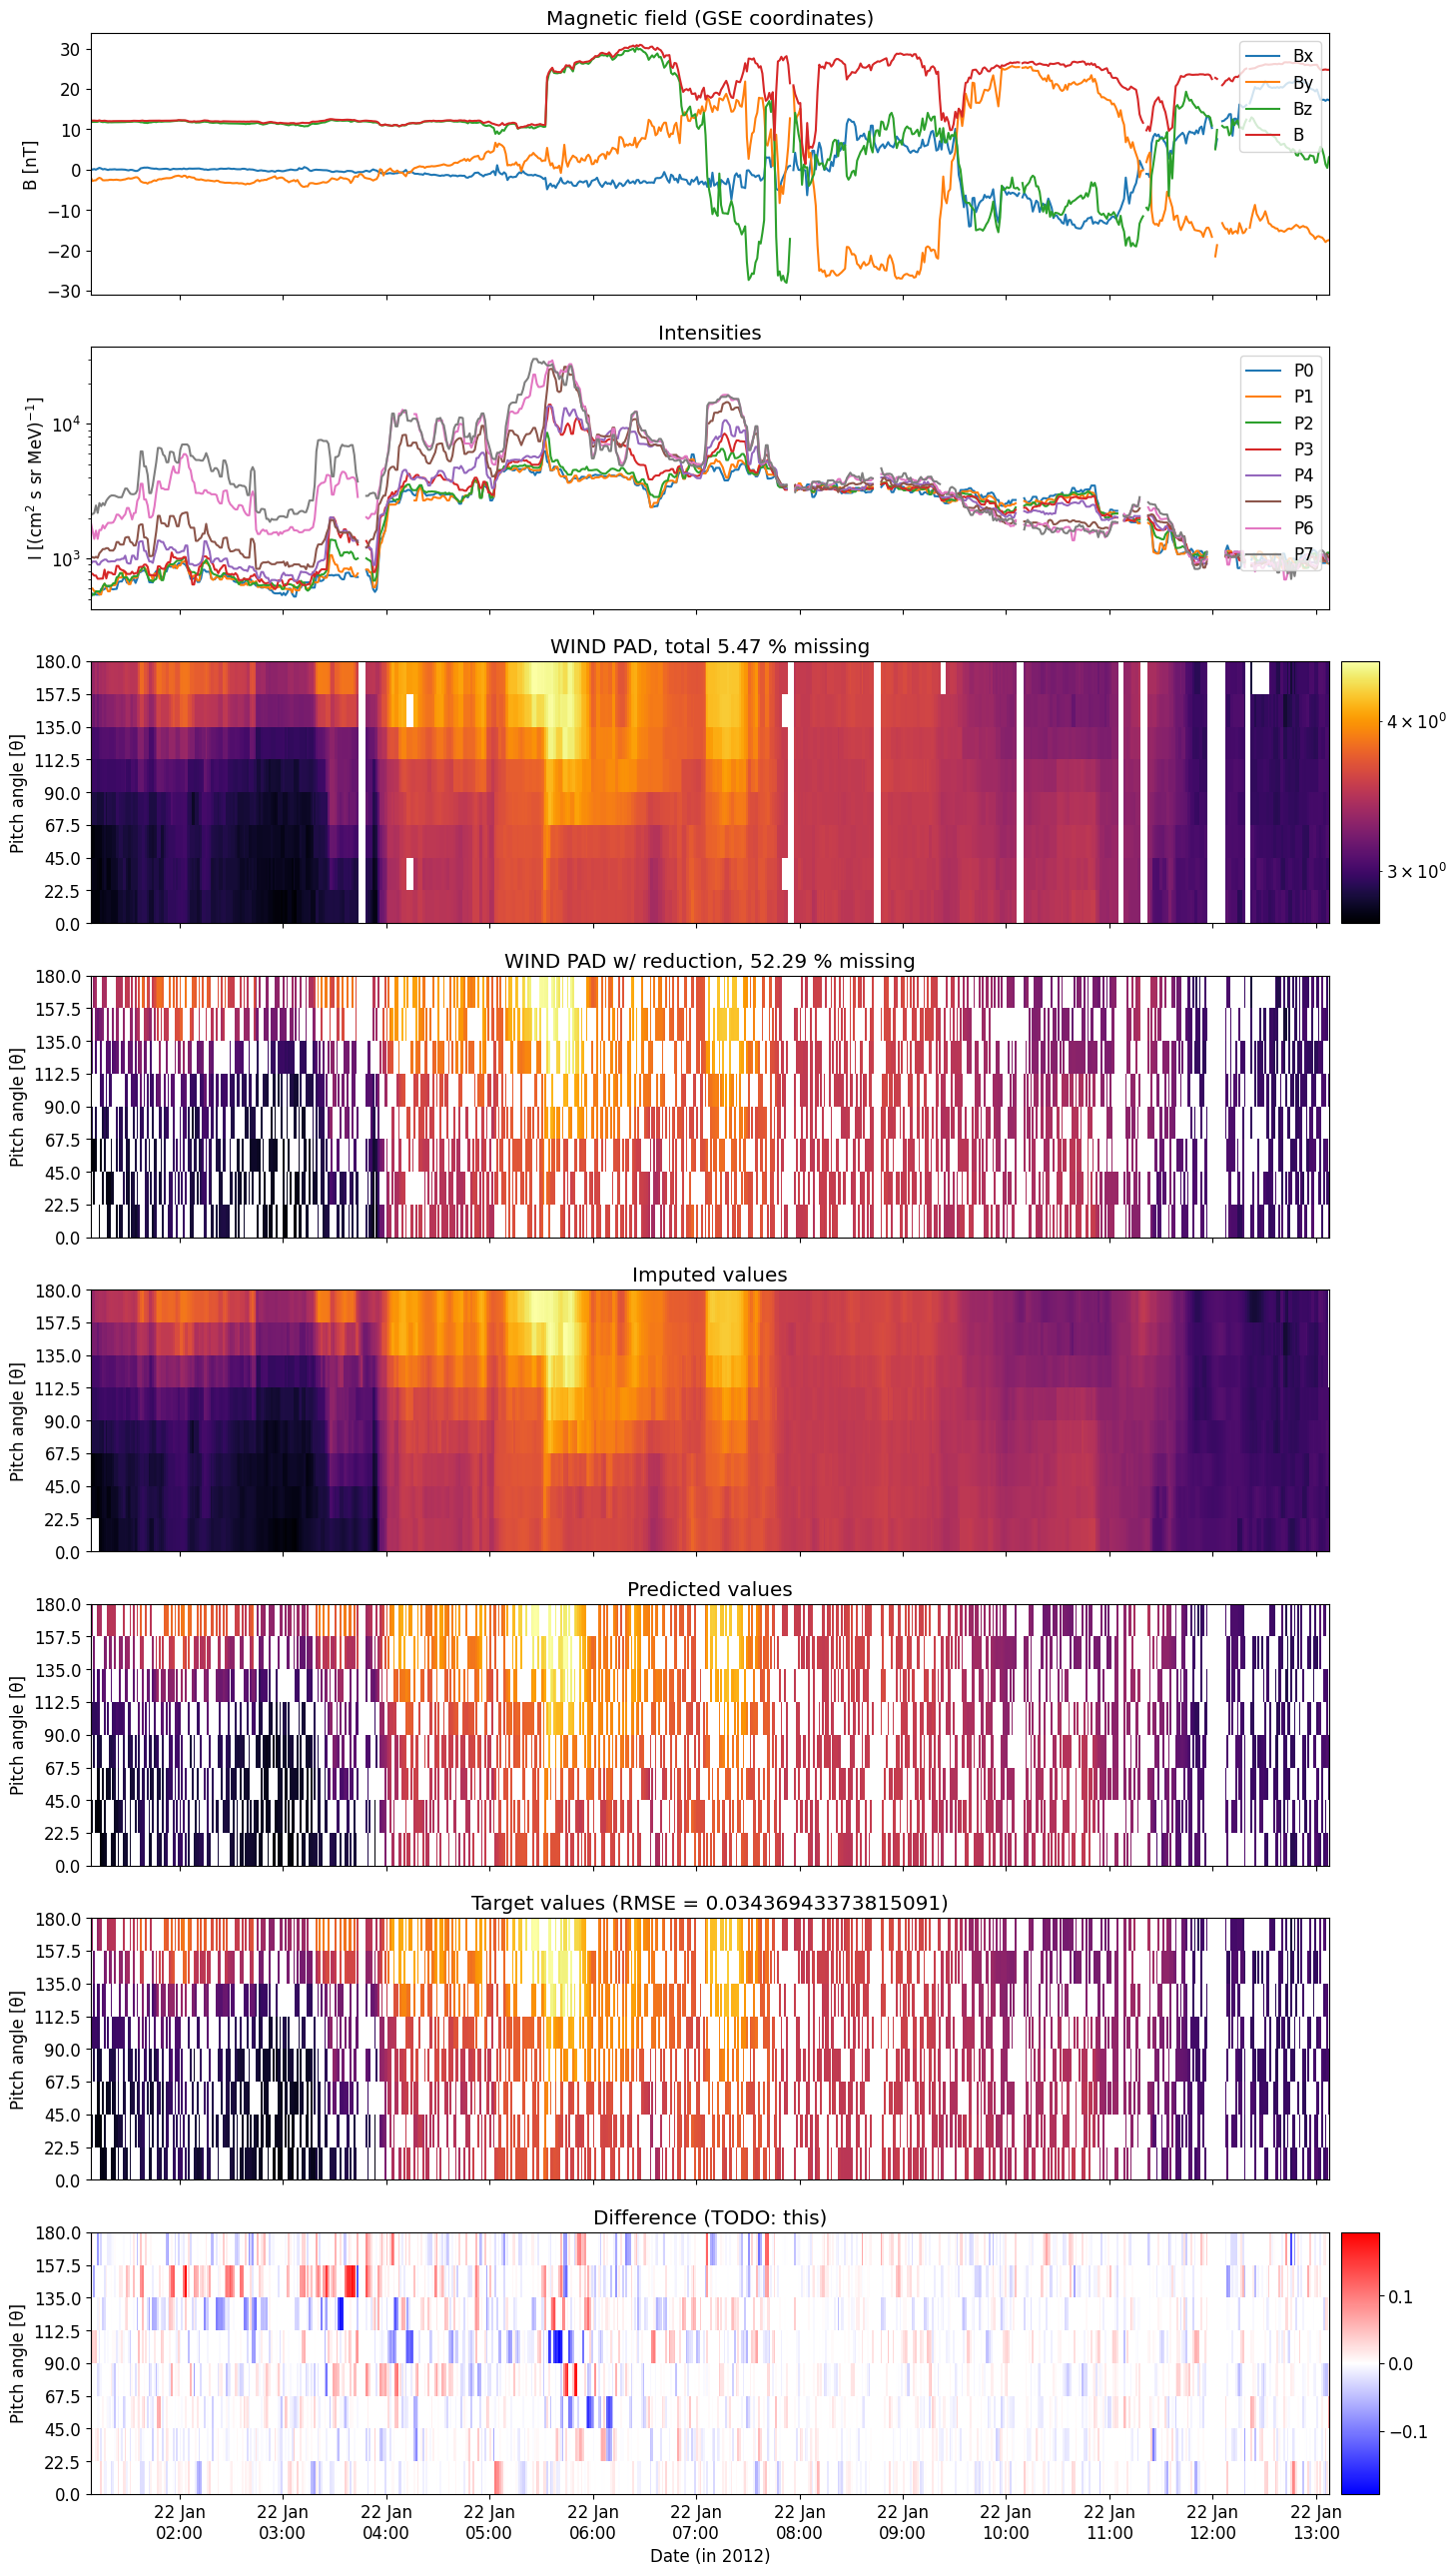

In [4]:
sc = WindConstants()
imputer = PADImputer(sc, method="cubic2d")
repeats = 100
miss_pct = 50
with h5py.File(file_path, 'r') as hdf:
    event_list = list(hdf.keys())
    event_key = event_list[1]
    imputer.run_analysis(event_key, miss_pct, repeats, scale="log", save_plot=False, file_path=file_path,
                         results_path=Path("."))

Clough-Tocher (piecewise cubic, curvature-minimizing) 2D interpolation (70 % MCAR)
Mean: 0.1984759526201289
Std: 0.014780895624314179


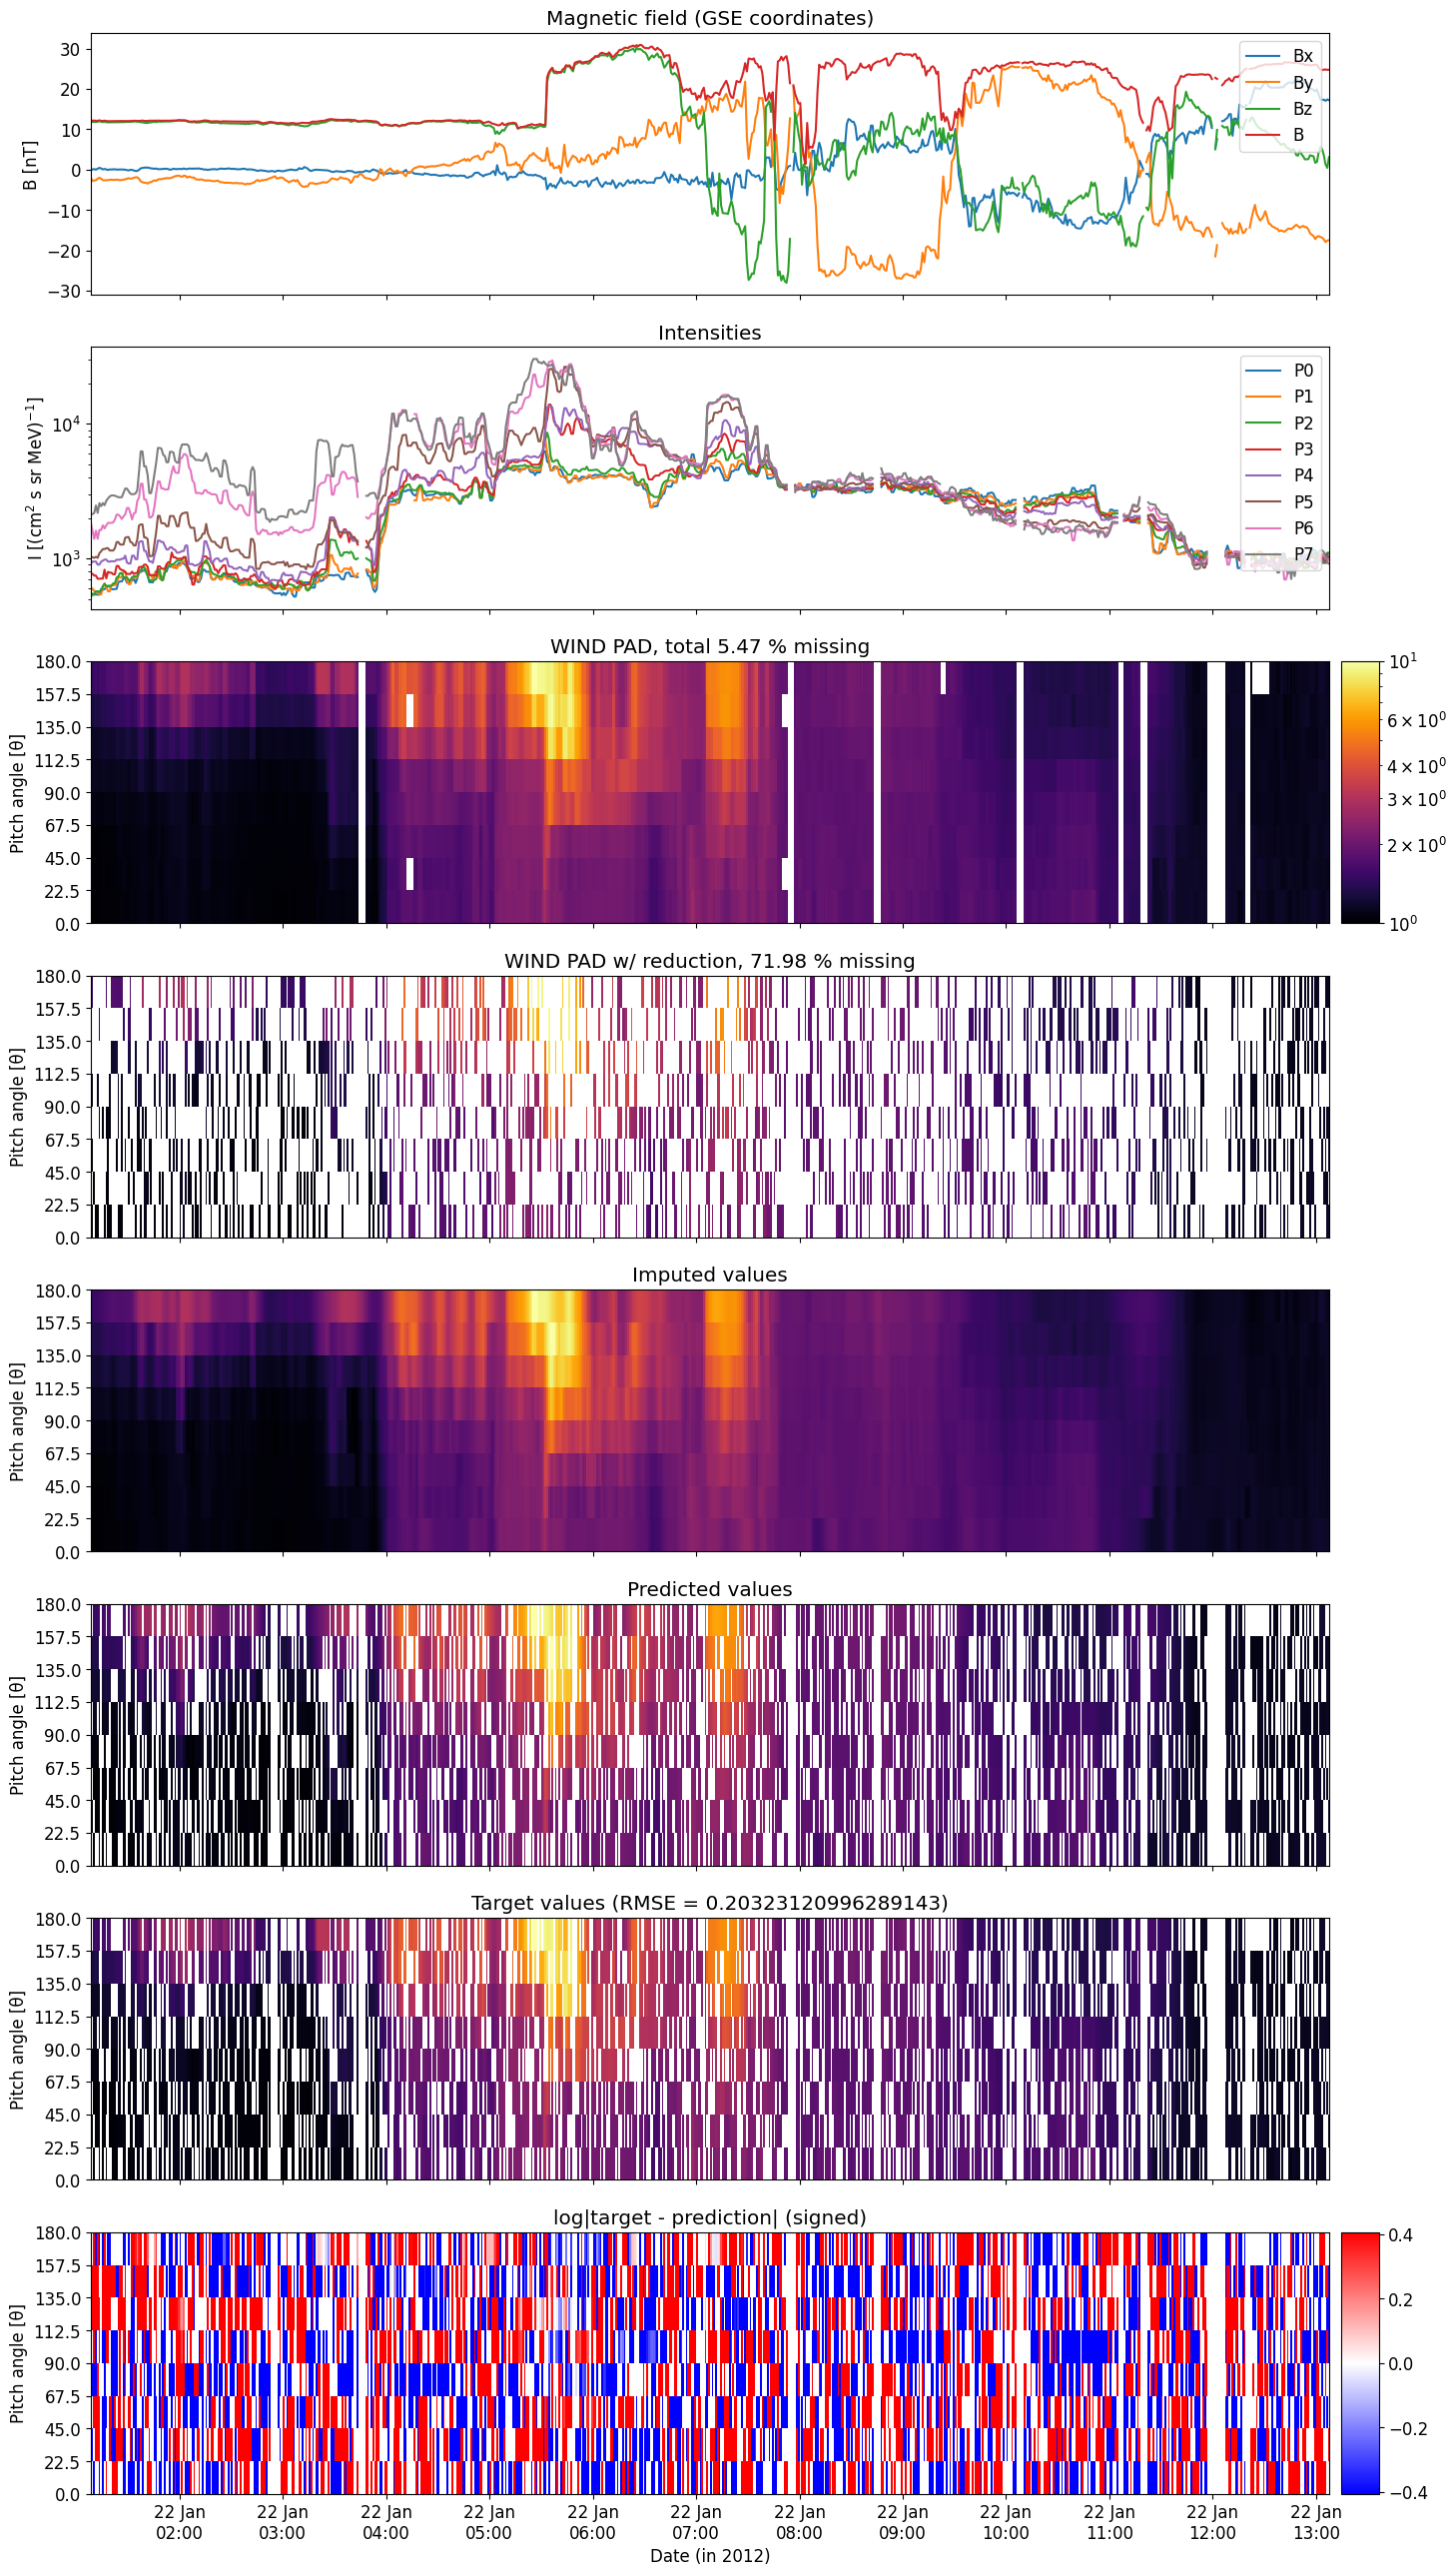

In [3]:
from aipad.pad_imputation import load_event_data, plot_results
from scipy.interpolate import griddata

def min_max_scale(a, interval=(0, 1)):
    return interval[0] + (interval[1] - interval[0])*(a - np.nanmin(a)) / (np.nanmax(a) - np.nanmin(a))

imputer = PADImputer(method="cubic", axis=0, cubic_dim=2)
repeats = 100
with h5py.File(file_path, 'r') as hdf:
    event_key = "20120122-030734"
    df = pd.read_csv(f"/home/ojsant/gradu/results/{event_key}.csv", header=0, index_col=[0, 1])
    event_data = load_event_data(hdf, event_key, wind)

    I_data = event_data["Intensity"]
    B_data = event_data["MagField"]
    cov_data = event_data["Coverage"]
    times = event_data["Intensity_attrs"]["Epoch"]

    I_min_max = min_max_scale(I_data.values, (1,10))

    X, Y, true = pad_histogram(wind, I_min_max, cov_data, 8)
    X, Y = np.meshgrid(np.arange(true.shape[0]), np.arange(true.shape[1]), indexing="ij")
    scores = []
    for i in range(repeats):
        reduced_cov, mask = induce_missingness(cov_data, 0.7)
        Xr, Yr, reduced = pad_histogram(wind, I_min_max, reduced_cov, 8)
        imputed = imputer.transform(reduced)
        target, pred = target_from_prediction(true, reduced, imputed)
        score = calculate_scores(target, pred, "rmse")
        scores.append(score)

    mean = np.mean(scores)
    std = np.std(scores, ddof=1)
    print("Clough-Tocher (piecewise cubic, curvature-minimizing) 2D interpolation (70 % MCAR)")
    print("Mean:", mean)
    print("Std:", std)
    pa = np.linspace(0.5*180/bins, (bins-0.5)*180/bins, bins)
    plot_results(pa, I_data, B_data, true, reduced, imputed, "rmse", wind, solo, save_plot=False)

In [1]:
imputer = PADImputer()
repeats = 100
with h5py.File(file_path, 'r') as hdf:
    
    df = pd.read_csv(f"./results/{event_key}.csv", header=[0, 1], index_col=[0, 1])
    
    event_data = load_event_data(hdf, event_key, wind)

    I_data = min_max_scale(event_data["Intensity"], (1, 10))
    B_data = event_data["MagField"]
    cov_data = event_data["Coverage"]
    times = event_data["Intensity_attrs"]["Epoch"]

    X, Y, true = pad_histogram(wind, I_data.values, cov_data, 8)
    imputer.method = "interp"
    imputer.axis = 0
    miss_percent = "70"
    scores = []
    
    for i in range(repeats):
        reduced_cov, mask = induce_missingness(cov_data, int(miss_percent) / 100)
        X, Y, reduced = pad_histogram(wind, I_data.values, reduced_cov, 8)
        imputed = imputer.fit_transform(reduced)
        target, pred = target_from_prediction(true, reduced, imputed)
        score = calculate_scores(target, pred, "rmse")
        scores.append(score)

    scores = np.array(scores)
    mean = scores.mean()
    std = scores.std(ddof=1)
    print("Linear 1D interpolation in time direction (70 % MCAR)")
    print("Mean:", mean)
    print("Std:", std)
    
    plot_results(Y[0], I_data, B_data, true, reduced, imputed, "rmse", wind, solo,
                 save_plot=False)

NameError: name 'PADImputer' is not defined

In [ ]:
from anisotropy.solo_methods import angle_between
from tqdm import tqdm

def calc_coverage(mag_data):
    opening = 40
    mag_vec = np.array([mag_data.Bx.to_numpy(), mag_data.By.to_numpy(), mag_data.Bz.to_numpy()])
    pointing_sun = np.array([-0.81915206, 0.57357645, 0.])
    pointing_asun = np.array([0.81915206, -0.57357645, 0.])
    pointing_north = np.array([0.30301532, 0.47649285, -0.8253098])
    pointing_south = np.array([-0.30301532, -0.47649285, 0.8253098])
    pointing_arr = np.vstack((pointing_sun, pointing_asun, pointing_north, pointing_south))

    pointing_sun = pointing_arr[0,:]
    pointing_asun = pointing_arr[1,:]
    pointing_north = pointing_arr[2,:]
    pointing_south = pointing_arr[3,:]
    pa_sun = np.ones(len(mag_data.Bx.to_numpy())) * np.nan
    pa_asun = np.ones(len(mag_data.Bx.to_numpy())) * np.nan
    pa_north = np.ones(len(mag_data.Bx.to_numpy())) * np.nan
    pa_south = np.ones(len(mag_data.Bx.to_numpy())) * np.nan

    for i in tqdm(range(len(mag_data.Bx.to_numpy()))):
        pa_sun[i] = np.rad2deg(angle_between(pointing_sun, mag_vec[:, i]))
        pa_asun[i] = np.rad2deg(angle_between(pointing_asun, mag_vec[:, i]))
        pa_north[i] = np.rad2deg(angle_between(pointing_north, mag_vec[:, i]))
        pa_south[i] = np.rad2deg(angle_between(pointing_south, mag_vec[:, i]))
    
    sun_min = pa_sun - opening/2
    sun_max = pa_sun + opening/2
    asun_min = pa_asun - opening/2
    asun_max = pa_asun + opening/2
    north_min = pa_north - opening/2
    north_max = pa_north + opening/2
    south_min = pa_south - opening/2
    south_max = pa_south + opening/2
    cov_sun = pd.DataFrame({'min': sun_min, 'center': pa_sun, 'max': sun_max}, index=mag_data.index)
    cov_asun = pd.DataFrame({'min': asun_min, 'center': pa_asun, 'max': asun_max}, index=mag_data.index)
    cov_north = pd.DataFrame({'min': north_min, 'center': pa_north, 'max': north_max}, index=mag_data.index)
    cov_south = pd.DataFrame({'min': south_min, 'center': pa_south, 'max': south_max}, index=mag_data.index)
    keys = [('sun'), ('asun'), ('north'), ('south')]
    coverage = pd.concat([cov_sun, cov_asun, cov_north, cov_south], keys=keys, axis=1)
    return coverage

cov = calc_coverage(B_data)
cov

100%|██████████| 1440/1440 [00:00<00:00, 9627.54it/s]


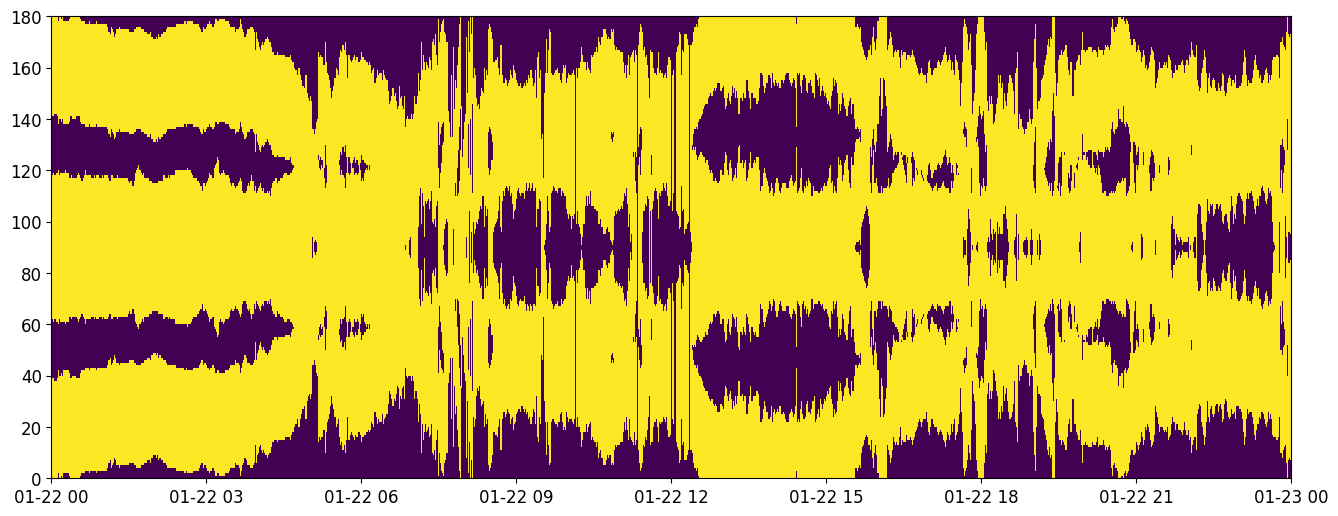

In [9]:
from aipad.pad_imputation import convert_to_bool_coverage

X, Y, wind_cov_bool = convert_to_bool_coverage(cov, solo, bins=180)
fig, ax = plt.subplots(figsize=(16,6))
ax.pcolormesh(X, Y, wind_cov_bool)

In [ ]:
imputer = PADImputer()
miss_pct = 10
index = pd.MultiIndex.from_product([method, ["time", "pitch_angle"]],
                                   names=["method", "axis"])
columns = pd.MultiIndex.from_product([["rmse_mean", "rmse_std"], [str(miss_pct)]],
                                    names=["stat", "miss_percent"])

df = pd.DataFrame(index=index, columns=columns)
df.loc[("mean", "time"), ("rmse_mean", str(20))] = 10
df.to_csv("test.csv")

In [28]:
df = pd.read_csv("test.csv", header=[0, 1], index_col=[0, 1])
df.loc[("mean2", "time"), ("rmse_mean", str(55))] = 10
df

stat                     rmse_mean rmse_std rmse_mean      
miss_percent                    10       10        20    55
method       axis                                          
mean         time              NaN      NaN      10.0   NaN
             pitch_angle       NaN      NaN       NaN   NaN
fill_average time              NaN      NaN       NaN   NaN
             pitch_angle       NaN      NaN       NaN   NaN
interp       time              NaN      NaN       NaN   NaN
             pitch_angle       NaN      NaN       NaN   NaN
knn          time              NaN      NaN       NaN   NaN
             pitch_angle       NaN      NaN       NaN   NaN
cubic        time              NaN      NaN       NaN   NaN
             pitch_angle       NaN      NaN       NaN   NaN
mean2        time              NaN      NaN       NaN  10.0

In [ ]:
%matplotlib widget

# importing required libraries
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import LinearNDInterpolator
import matplotlib.pyplot as plt

# creating figure
fig = plt.figure()
ax = Axes3D(fig)

# creating the plot
rng = np.random.default_rng()
x = rng.random(10) - 0.5
y = rng.random(10) - 0.5
z = np.hypot(x, y)
X = np.linspace(min(x), max(x))
Y = np.linspace(min(y), max(y))
X, Y = np.meshgrid(X, Y)  # 2D grid for interpolation
interp = LinearNDInterpolator(list(zip(x, y)), z)
Z = interp(X, Y)
ax.plot_surface(X, Y, Z, cmap="viridis")
#ax.scatter(x, y, z)
#ax.legend()
#ax.axis("equal")

# setting title and labels
ax.set_title("3D plot")
ax.set_xlabel('x-axis')
ax.set_ylabel('y-axis')
ax.set_zlabel('z-axis')

# displaying the plot
plt.show()

SyntaxError: invalid syntax (3710665958.py, line 5)

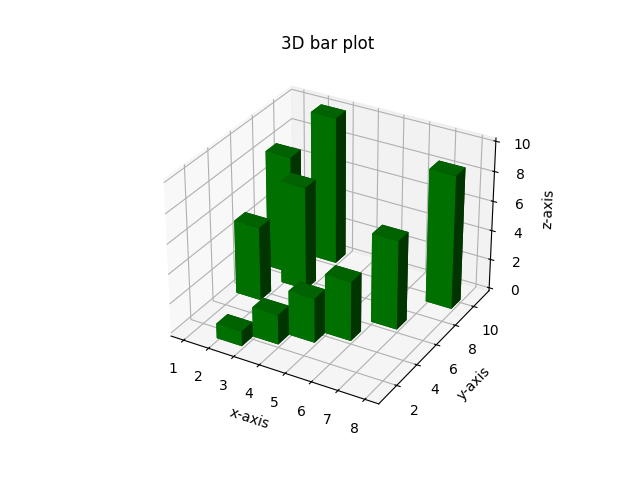

In [5]:
# creating 3d bar plot using matplotlib 
# in python

# to interact  with plot
%matplotlib widget

# importing required libraries
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

# creating random dataset
xs = [2, 3, 4, 5, 1, 6, 2, 1, 7, 2]
ys = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
zs = np.zeros(10)
dx = np.ones(10)
dy = np.ones(10)
dz = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# creating figure
figg = plt.figure()
ax = figg.add_subplot(111, projection='3d')

# creating the plot
plot_geeks = ax.bar3d(xs, ys, zs, dx, 
                      dy, dz, color='green')

# setting title and labels
ax.set_title("3D bar plot")
ax.set_xlabel('x-axis')
ax.set_ylabel('y-axis')
ax.set_zlabel('z-axis')

# displaying the plot
plt.show()

In [7]:
df = pd.read_csv("/home/ojsant/gradu/knn_results/20121009-080740.csv", header=0, index_col=[0, 1])

In [12]:
df.loc[("knn", "20n"), "10"] = 5.0
df.loc[("knn", "20n"), "40"] = 69.0
df.loc[("knn", "17n"), "10"] = 420.0

In [14]:
df.loc[("knn", "17n"), "40"] = 67
df

10          20          50  \
method             n_neighbors                                       
knn                1n           179.360073  363.650210  691.149858   
                   5n           145.725818  280.546450  548.589906   
                   10n          155.034813  268.961143  548.285656   
                   15n          158.231800  280.732779  560.182296   
knn_with_traintest 1n           199.579826  256.830691  762.435543   
                   5n           193.727535  255.549605  626.496671   
                   10n          228.779039  288.929641  566.630936   
                   15n          271.122787  309.388706  571.223823   
knn                20n            5.000000         NaN         NaN   
                   17n          420.000000         NaN         NaN   

                                         80  ((knn, 20n), 10)    40  
method             n_neighbors                                       
knn                1n            764.817659               5.0   NaN  
                   5n            706.839286               5.0   NaN  
                   10n           818.592468               5.0   NaN  
                   15n           934.430125               5.0   NaN  
knn_with_traintest 1n           1118.284449               5.0   NaN  
                   5n           1042.523661               5.0   NaN  
                   10n          1040.353434               5.0   NaN  
                   15n          1035.445459               5.0   NaN  
knn                20n                  NaN               NaN  69.0  
                   17n                  NaN               NaN  67.0

In [4]:
x = np.array([10000, 20000, 30000, 40000])
print(np.log10(x))
print(10 ** np.log10(x))

[4.         4.30103    4.47712125 4.60205999]
[10000. 20000. 30000. 40000.]
